# Convolution as Sliding Area

The **convolution** of two signals $h$ and $g$ is defined as:

$$
(h \ast g)(t) = \int_{-\infty}^{\infty} h(\tau)\, g(t - \tau)\, d\tau
$$

For each fixed value of $t$, the integral computes the **area under the pointwise product** of $h(\tau)$ and a flipped, shifted copy of $g$. Four mechanical steps:

| Step | Operation | Effect |
|------|-----------|--------|
| **Flip** | $g(\tau)\to g(-\tau)$ | mirror $g$ around $\tau = 0$ |
| **Shift** | $g(-\tau)\to g(t-\tau)$ | slide the mirror to position $t$ |
| **Multiply** | $h(\tau)\cdot g(t-\tau)$ | pointwise product |
| **Integrate** | $\int(\cdots)\,d\tau$ | **area of the overlap** = one output sample |

Sweeping $t$ from $-\infty$ to $+\infty$ traces the complete output $(h \ast g)(t)$.  
Each output value equals the **area of the overlapping region** between $h(\tau)$ and $g(t-\tau)$.


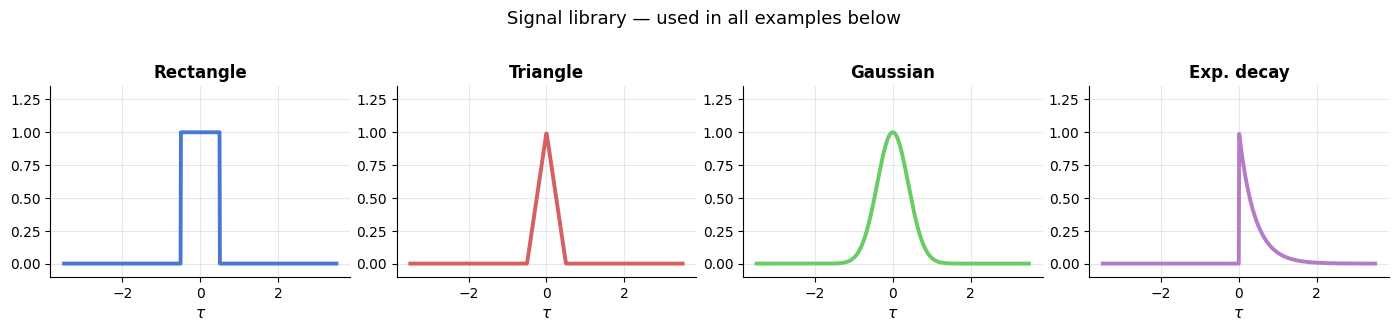

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, Dropdown, Checkbox

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False
})

def rect(t, w=1.0):   return np.where(np.abs(t) <= w / 2, 1.0, 0.0)
def tri(t, w=1.0):    return np.maximum(1.0 - np.abs(t) / (w / 2), 0.0)
def gauss(t, s=0.4):  return np.exp(-t ** 2 / (2 * s ** 2))
def exp_dec(t):        return np.where(t >= 0, np.exp(-2.5 * t), 0.0)

SIGNALS = {'Rectangle': rect, 'Triangle': tri, 'Gaussian': gauss, 'Exp. decay': exp_dec}
PAL = ['#4878CF', '#D65F5F', '#6ACC65', '#B47CC7']

tau_prev = np.linspace(-3.5, 3.5, 700)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (name, fn), c in zip(axes, SIGNALS.items(), PAL):
    ax.plot(tau_prev, fn(tau_prev), color=c, lw=2.8)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$\tau$', fontsize=11)
    ax.set_ylim(-0.1, 1.35)
plt.suptitle('Signal library — used in all examples below', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## rect $\ast$ rect — Step-by-Step

The rectangle is symmetric, so **flipping leaves it unchanged**: $g(-\tau) = g(\tau)$.  
The only visible effect of $t$ is a **pure horizontal slide**.

The exact closed-form output is:

$$
(\text{rect} \ast \text{rect})(t) = \max(1 - |t|,\;0) \qquad \text{— a triangle}
$$

**Three phases** as $t$ sweeps from $-3$ to $+3$:

1. **$|t| > 1$** — no overlap → output = 0  
2. **$-1 \le t \le 0$** — overlap grows linearly → output rises  
3. **$0 \le t \le 1$** — overlap shrinks → output falls to 0  

The output support is $[-1, 1]$, **twice** that of each input ($[-\tfrac{1}{2}, \tfrac{1}{2}]$).  
This generalises: convolving signals of widths $W_1$ and $W_2$ produces support $W_1 + W_2$.

Enable **Trace** to watch the output triangle build point-by-point as you drag the slider.


In [ ]:
TAU = np.linspace(-4, 4, 800)
DT  = TAU[1] - TAU[0]

_h    = rect(TAU)
_g    = rect(TAU)
_conv = np.convolve(_h, _g, 'full') * DT
_tc   = np.linspace(2 * TAU[0], 2 * TAU[-1], len(_conv))

def show_rect_conv(t=0.0, trace=True):
    g_sl = rect(t - TAU)
    prod = _h * g_sl
    area = float(np.trapezoid(prod, TAU))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6),
                                   gridspec_kw={'wspace': 0.32})
    ax1.plot(TAU, _h,   color='#4878CF', lw=2.8, label=r'$h(\tau)$ — fixed')
    ax1.plot(TAU, g_sl, color='#D65F5F', lw=2.8,
             label='$g(t-\\tau)$,  $t = {:.2f}$'.format(t))
    ax1.fill_between(TAU, prod, where=prod > 1e-9,
                     color='#6ACC65', alpha=0.5,
                     label='overlap area = {:.3f}'.format(area))
    ax1.set(xlim=(-3.2, 3.2), ylim=(-0.15, 1.85),
            xlabel=r'$\tau$', title='Flip & Slide  (τ domain)')
    ax1.legend(fontsize=10)

    mask = _tc <= t
    if trace:
        ax2.plot(_tc[mask],  _conv[mask],  color='#B47CC7', lw=2.8, label='traced so far')
        ax2.plot(_tc[~mask], _conv[~mask], color='#B47CC7', lw=1.2,
                 alpha=0.18, ls='--', label='to be traced')
    else:
        ax2.plot(_tc, _conv, color='#B47CC7', lw=2.8, label=r'$(h \ast g)(t)$')
    ax2.axvline(t, color='#D65F5F', ls='--', lw=1.5, alpha=0.85)
    ax2.scatter([t], [area], color='#D65F5F', s=110, zorder=6,
                label='current value: {:.3f}'.format(area))
    ax2.set(xlim=(-3.2, 3.2), ylim=(-0.1, 1.28),
            xlabel=r'$t$', title=r'Convolution Output $(h \ast g)(t)$')
    ax2.legend(fontsize=10)
    plt.show()

interact(
    show_rect_conv,
    t=FloatSlider(min=-3.0, max=3.0, step=0.05, value=-1.5,
                  description='t', continuous_update=True,
                  style={'description_width': 'initial'}),
    trace=Checkbox(value=True, description='Trace output as t grows')
)


interactive(children=(FloatSlider(value=-1.5, description='t', max=3.0, min=-3.0, step=0.05, style=SliderStyle…

<function __main__.show_rect_conv(t=0.0, trace=True)>

## Beyond Rectangles — Signal Pairs & Their Shapes

The geometric picture generalises to any integrable signals:

| $h(t)$ | $g(t)$ | Output shape | Geometric reason |
|--------|--------|--------------|-----------------|
| rect | rect | **triangle** | overlap area changes linearly |
| rect | Gaussian | **smoothed rect** | Gaussian blurs the sharp step edges |
| Gaussian | Gaussian | **wider Gaussian** | $\sigma_{\rm out}^2 = \sigma_h^2 + \sigma_g^2$ |
| rect | exp. decay | **exponential charge** | area of sliding decay under a window |
| exp. decay | exp. decay | $t\,e^{-at}u(t)$ | Erlang-2 envelope |

The convolution is **precomputed and cached** the first time each pair is selected, so dragging the slider stays fluid regardless of signal choice.


In [ ]:
_CACHE = {}

def _get_conv(hn, gn):
    if (hn, gn) not in _CACHE:
        tau_l = np.linspace(-5, 5, 1200)
        dl    = tau_l[1] - tau_l[0]
        hv    = SIGNALS[hn](tau_l)
        gv    = SIGNALS[gn](tau_l)
        cv    = scipy.signal.fftconvolve(hv, gv, 'full') * dl
        tc    = np.linspace(2 * tau_l[0], 2 * tau_l[-1], len(cv))
        _CACHE[(hn, gn)] = (tau_l, hv, cv, tc)
    return _CACHE[(hn, gn)]

def show_custom_conv(h_name='Rectangle', g_name='Gaussian', t=0.0, trace=True):
    tau_l, hv, conv, t_c = _get_conv(h_name, g_name)
    g_sl = SIGNALS[g_name](t - tau_l)
    prod = hv * g_sl
    area = float(np.trapezoid(prod, tau_l))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6),
                                   gridspec_kw={'wspace': 0.32})
    ax1.plot(tau_l, hv,   color='#4878CF', lw=2.8,
             label='$h(\\tau)$ = {}'.format(h_name))
    ax1.plot(tau_l, g_sl, color='#D65F5F', lw=2.8,
             label='$g(t-\\tau)$ = {},   t = {:.2f}'.format(g_name, t))
    ax1.fill_between(tau_l, prod, where=prod > 1e-9,
                     color='#6ACC65', alpha=0.5,
                     label='area = {:.3f}'.format(area))
    ax1.set(xlim=(-5.5, 5.5), ylim=(-0.15, 1.85),
            xlabel=r'$\tau$', title='Flip & Slide')
    ax1.legend(fontsize=9)

    mask = t_c <= t
    if trace:
        ax2.plot(t_c[mask],  conv[mask],  color='#B47CC7', lw=2.8, label='traced so far')
        ax2.plot(t_c[~mask], conv[~mask], color='#B47CC7', lw=1.2,
                 alpha=0.18, ls='--', label='to be traced')
    else:
        ax2.plot(t_c, conv, color='#B47CC7', lw=2.8, label=r'$(h \ast g)(t)$')
    ax2.axvline(t, color='#D65F5F', ls='--', lw=1.5, alpha=0.85)
    ax2.scatter([t], [area], color='#D65F5F', s=110, zorder=6,
                label='current: {:.3f}'.format(area))
    ax2.set(xlim=(-5.5, 5.5), xlabel=r'$t$', title='Convolution Output')
    ax2.legend(fontsize=9)
    plt.show()

h_dd  = Dropdown(options=list(SIGNALS), value='Rectangle', description='h(t):')
g_dd  = Dropdown(options=list(SIGNALS), value='Gaussian',  description='g(t):')
t_sl  = FloatSlider(min=-5.0, max=5.0, step=0.05, value=-2.5,
                    description='t', continuous_update=True,
                    style={'description_width': 'initial'})
tr_cb = Checkbox(value=True, description='Trace output')

interact(show_custom_conv, h_name=h_dd, g_name=g_dd, t=t_sl, trace=tr_cb)


interactive(children=(Dropdown(description='h(t):', options=('Rectangle', 'Triangle', 'Gaussian', 'Exp. decay'…

<function __main__.show_custom_conv(h_name='Rectangle', g_name='Gaussian', t=0.0, trace=True)>

## Discrete Approximation & Fast Computation

Sampling the integral with step $\Delta\tau$ gives a finite sum:

$$
(h \ast g)[n] \approx \left(\sum_{k=0}^{N-1} h[k]\; g[n - k]\right) \cdot \Delta\tau
$$

The output has $2N - 1$ samples and spans $[2\tau_{\min},\;2\tau_{\max}]$.

| Implementation | Complexity | When to prefer |
|---------------|-----------|---------------|
| `np.convolve(h, g, 'full') * dt` | $O(N^2)$ | $N \lesssim 10^4$ |
| `scipy.signal.fftconvolve(h, g) * dt` | $O(N\log N)$ | $N \gtrsim 10^4$ |

The FFT route applies the **convolution theorem**: $\;h \ast g = \mathcal{F}^{-1}\!\left\{\hat{h}\cdot\hat{g}\right\}$.  
Both produce **numerically identical** results, confirmed below.


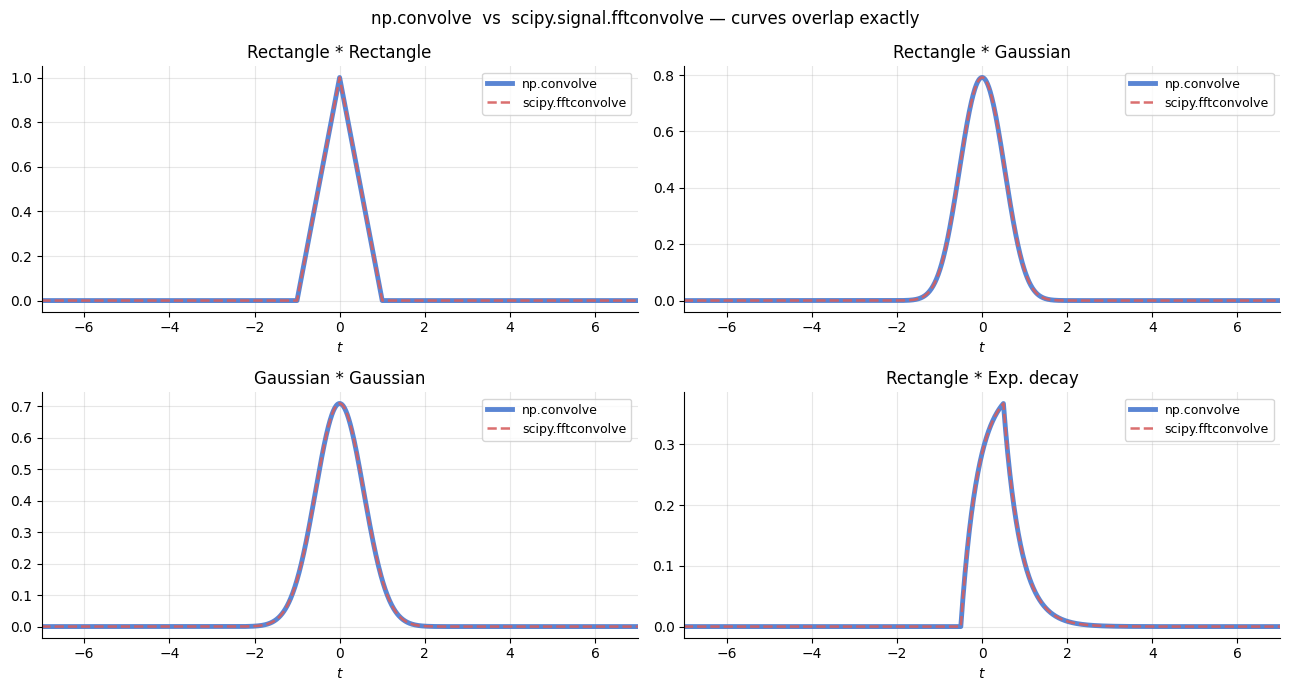

Max absolute difference (direct vs FFT) per pair:
  Rectangle    * Rectangle     ->  2.84e-14
  Rectangle    * Gaussian      ->  2.84e-14
  Gaussian     * Gaussian      ->  2.84e-14
  Rectangle    * Exp. decay    ->  1.07e-14


In [4]:
tau_v = np.linspace(-4, 4, 800)
dtv   = tau_v[1] - tau_v[0]
t_out = np.linspace(2 * tau_v[0], 2 * tau_v[-1], 2 * len(tau_v) - 1)

pairs = [('Rectangle', 'Rectangle'), ('Rectangle', 'Gaussian'),
         ('Gaussian',  'Gaussian'),   ('Rectangle', 'Exp. decay')]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (hn, gn) in zip(axes.ravel(), pairs):
    hv    = SIGNALS[hn](tau_v)
    gv    = SIGNALS[gn](tau_v)
    c_np  = np.convolve(hv, gv, 'full') * dtv
    c_fft = scipy.signal.fftconvolve(hv, gv, 'full') * dtv
    ax.plot(t_out, c_np,  color='#4878CF', lw=3.5, alpha=0.9, label='np.convolve')
    ax.plot(t_out, c_fft, color='#D65F5F', lw=1.8, ls='--', alpha=0.9,
            label='scipy.fftconvolve')
    ax.set(title='{} * {}'.format(hn, gn), xlabel=r'$t$', xlim=(-7, 7))
    ax.legend(fontsize=9)
plt.suptitle('np.convolve  vs  scipy.signal.fftconvolve — curves overlap exactly',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Max absolute difference (direct vs FFT) per pair:")
for hn, gn in pairs:
    err = np.max(np.abs(
        np.convolve(SIGNALS[hn](tau_v), SIGNALS[gn](tau_v), 'full') -
        scipy.signal.fftconvolve(SIGNALS[hn](tau_v), SIGNALS[gn](tau_v), 'full')
    ))
    print('  {:12s} * {:12s}  ->  {:.2e}'.format(hn, gn, err))
